In [1]:
!pip install geopandas rasterio earthengine-api geemap scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

Text(0.5, 1.0, 'Chanadai Union')

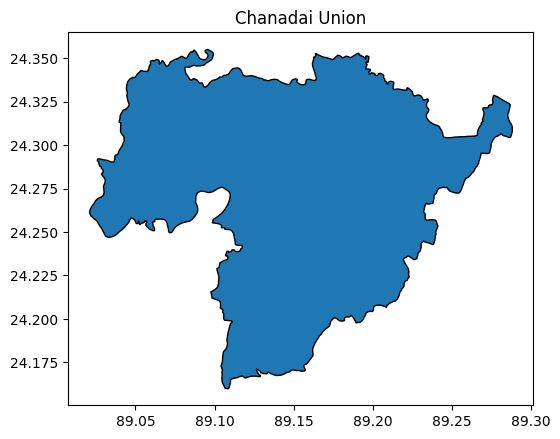

In [6]:
import os
os.environ['SHAPE_RESTORE_SHX'] = 'YES'

shapefile = "/content/Export_Output_2.shp"

district = gpd.read_file(shapefile)

district.plot(edgecolor='black', figsize=(6,6))
plt.title("Chanadai Union")

In [7]:
np.random.seed(42)

data = pd.DataFrame({

    "soil_moisture": np.random.uniform(10,40,300),
    "temperature": np.random.uniform(20,38,300),
    "rainfall": np.random.uniform(0,200,300),
    "humidity": np.random.uniform(40,90,300),
    "ndvi": np.random.uniform(0.2,0.9,300)

})

data["yield"] = (
    0.3*data.soil_moisture +
    0.2*data.rainfall +
    0.3*data.ndvi*100 +
    np.random.normal(0,5,300)
)

data.head()

,soil_moisture,temperature,rainfall,humidity,ndvi,yield
0,21.236204,20.930271,33.787013,50.394313,0.730784,22.554762
1,38.521429,29.564383,55.718068,41.326610,0.217211,40.671080
2,31.959818,29.731432,35.402097,49.071772,0.215486,16.185097
3,27.959755,31.473738,17.740507,69.152078,0.426527,16.504849
4,14.680559,33.069644,24.127174,61.071228,0.542050,30.603962


In [8]:
X = data.drop("yield", axis=1)
y = data["yield"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = RandomForestRegressor(n_estimators=200)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test,pred))

R2 Score: 0.7211635076310872


([0, 1, 2, 3, 4],
 [Text(0, 0, 'soil_moisture'),
  Text(1, 0, 'temperature'),
  Text(2, 0, 'rainfall'),
  Text(3, 0, 'humidity'),
  Text(4, 0, 'ndvi')])

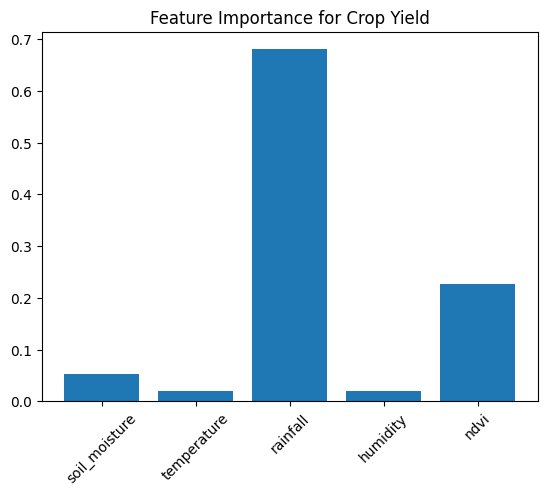

In [9]:
importance = model.feature_importances_

features = X.columns

plt.bar(features, importance)
plt.title("Feature Importance for Crop Yield")
plt.xticks(rotation=45)

Text(0.5, 1.0, 'Predicted Crop Yield Map')

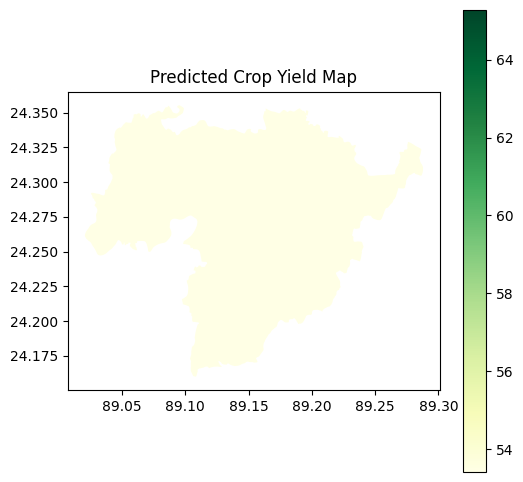

In [10]:
district["predicted_yield"] = np.random.uniform(50,120,len(district))

district.plot(column="predicted_yield",
              legend=True,
              cmap="YlGn",
              figsize=(6,6))

plt.title("Predicted Crop Yield Map")

In [11]:
!pip install geopandas folium

In [12]:
import geopandas as gpd
import folium
import pandas as pd
import numpy as np

In [13]:
shapefile = "/content/Export_Output_2.shp"

district = gpd.read_file(shapefile)

district.head()

,Shape_Leng,Shape_Area,ADM3_EN,ADM3_PCODE,ADM3_REF,ADM3ALT1EN,ADM3ALT2EN,ADM2_EN,ADM2_PCODE,ADM1_EN,ADM1_PCODE,ADM0_EN,ADM0_PCODE,date,validOn,validTo,geometry
0,1.17493,0.026663,Baraigram,BD506915,None,None,None,Natore,BD5069,Rajshahi,BD50,Bangladesh,BD,2015-01-01,2020-11-13,NaT,"POLYGON ((89.09783 24.34955, 89.09747 24.34926..."


In [14]:
district["predicted_yield"] = np.random.uniform(50,120,len(district))

In [15]:
center = district.geometry.centroid.iloc[0]

m = folium.Map(
    location=[center.y, center.x],
    zoom_start=9,
    tiles="cartodbpositron"
)

/tmp/ipykernel_769/1425279514.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = district.geometry.centroid.iloc[0]


In [17]:
# Convert non-serializable columns to string type for JSON compatibility
for col in ['date', 'validOn', 'validTo']:
    if col in district.columns:
        district[col] = district[col].astype(str)

folium.Choropleth(
    geo_data=district,
    data=district,
    columns=[district.index, "predicted_yield"],
    key_on="feature.id",
    fill_color="YlGn",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="Predicted Crop Yield"
).add_to(m)

In [18]:
folium.GeoJson(
    district,
    tooltip=folium.GeoJsonTooltip(
        fields=["predicted_yield"],
        aliases=["Yield:"]
    )
).add_to(m)

In [19]:
m

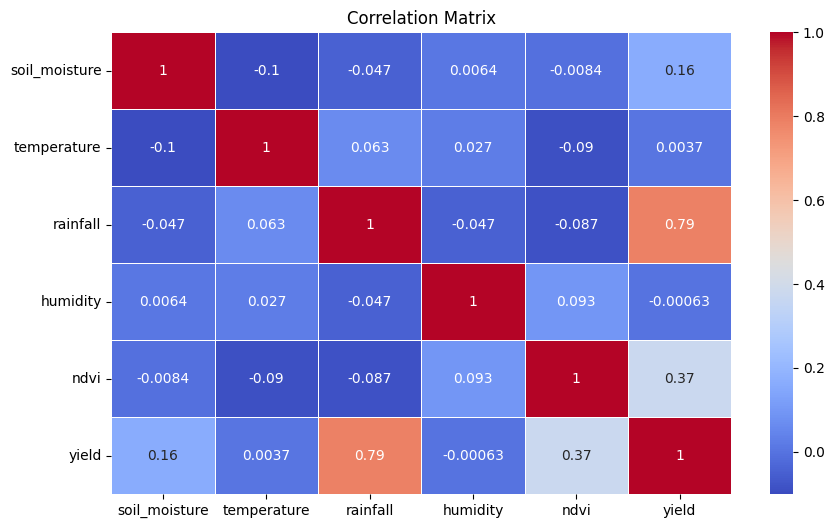

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

corr = data.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

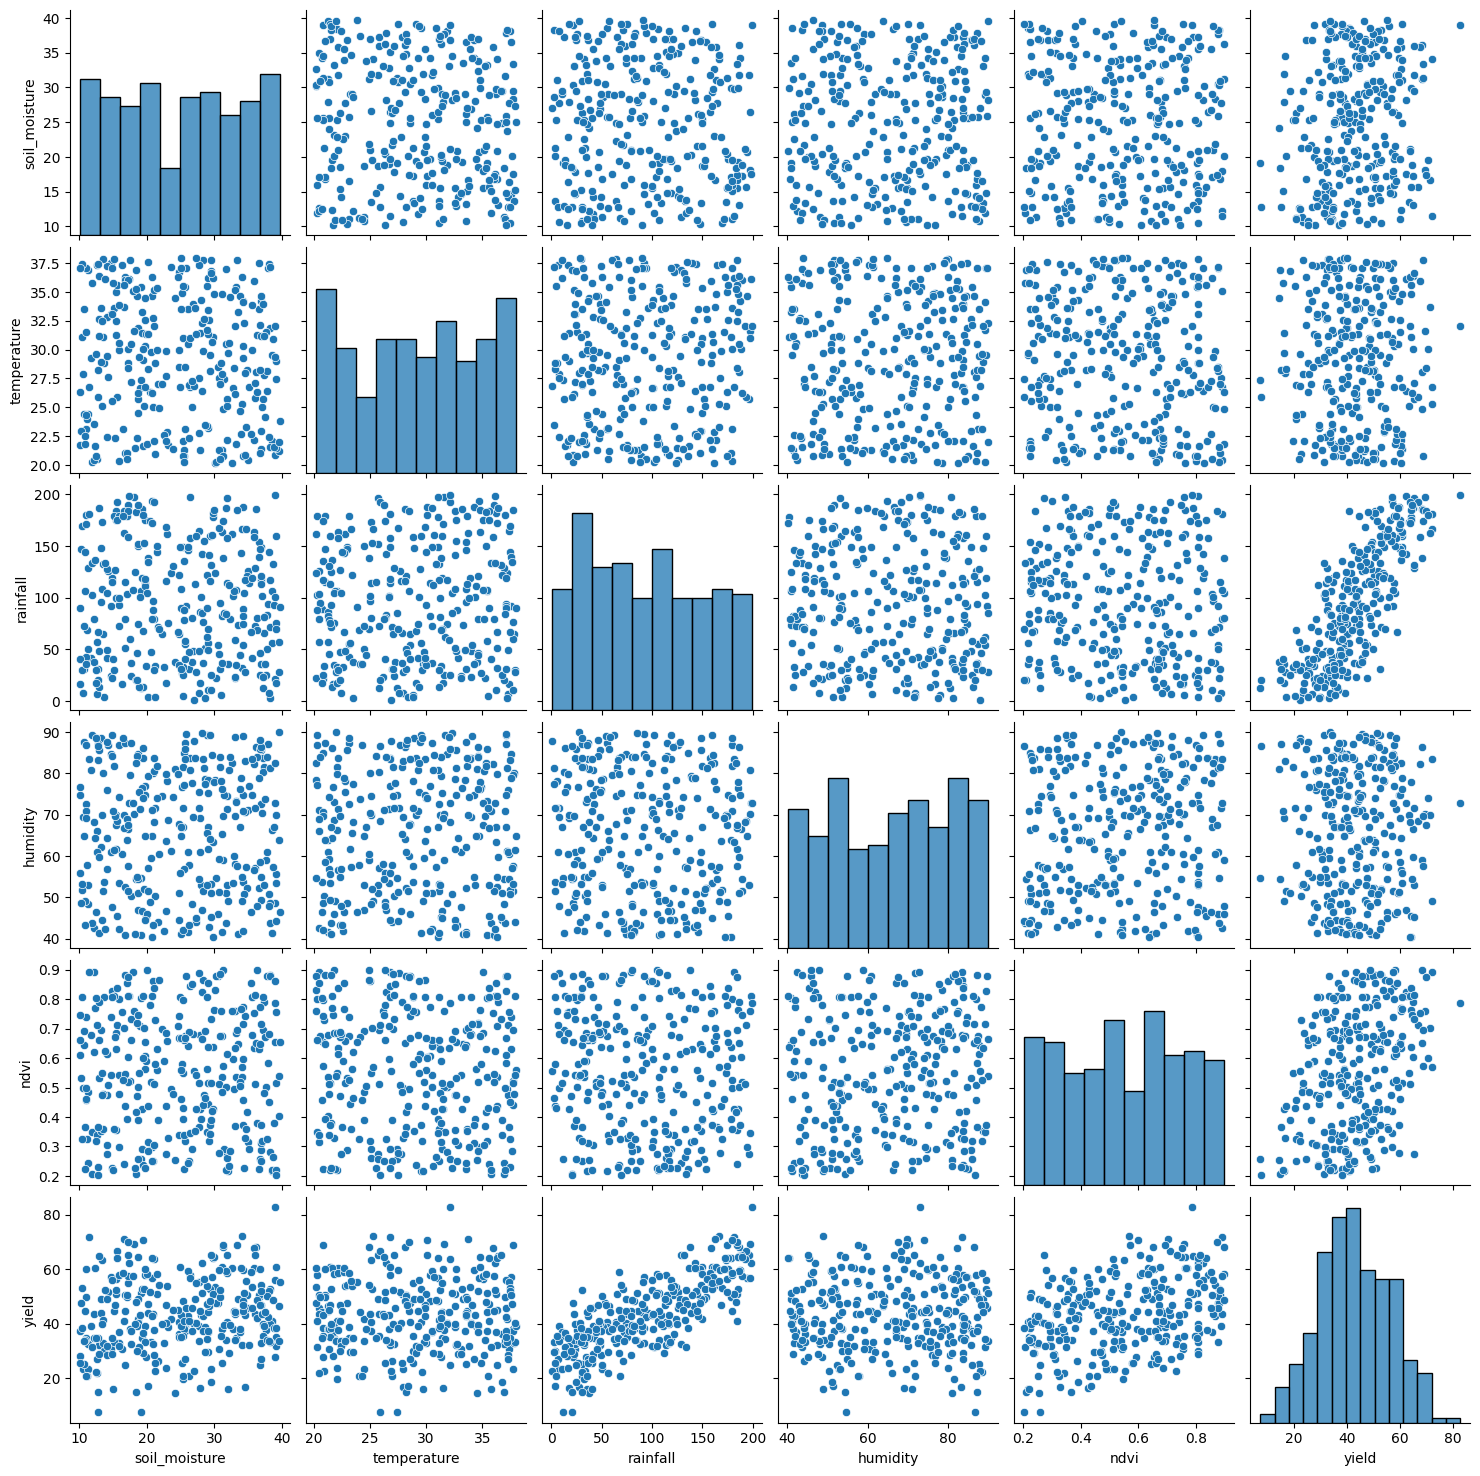

In [21]:
sns.pairplot(data)
plt.show()

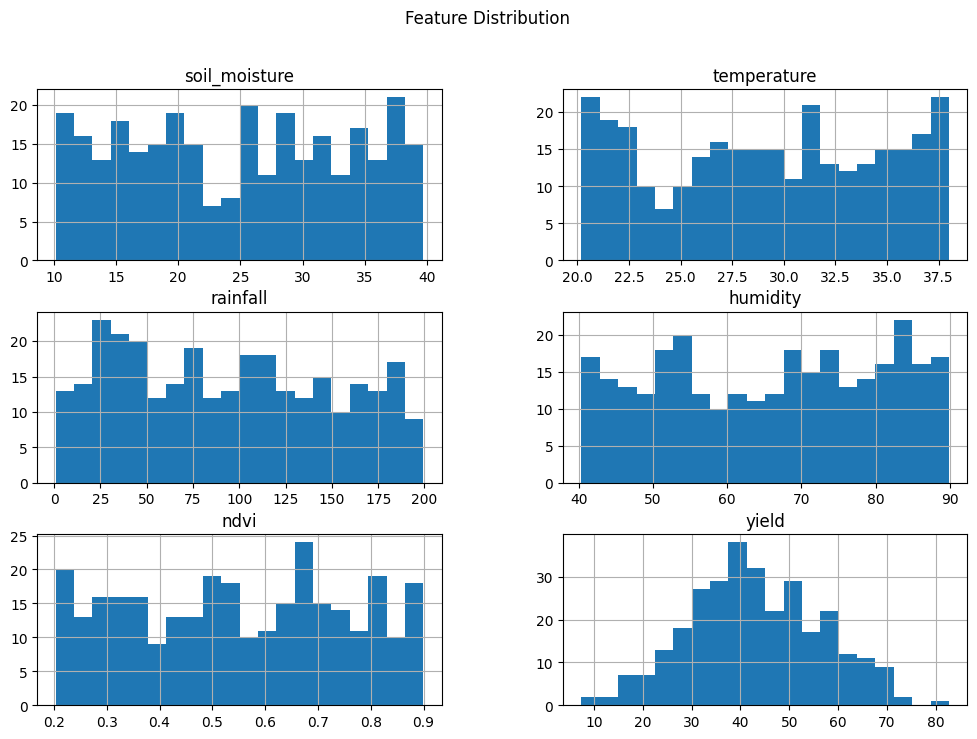

In [22]:
data.hist(
    figsize=(12,8),
    bins=20
)

plt.suptitle("Feature Distribution")
plt.show()

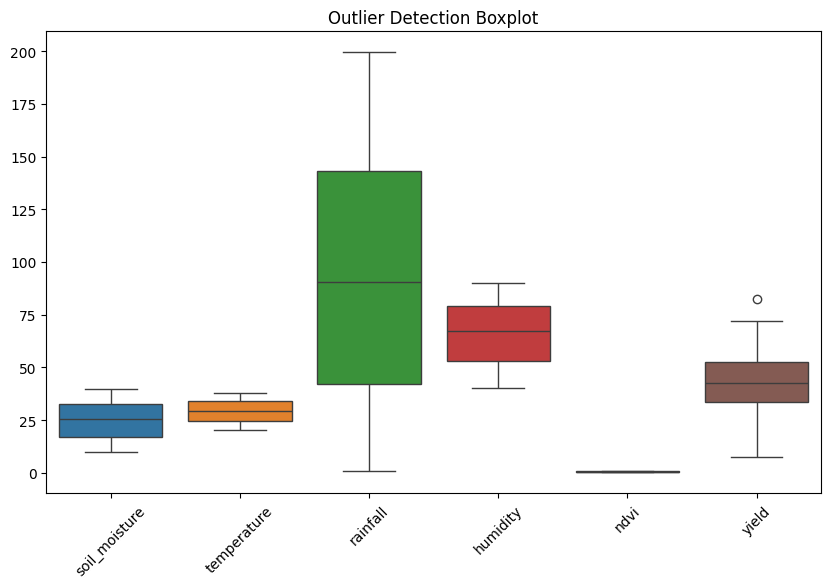

In [23]:
plt.figure(figsize=(10,6))

sns.boxplot(data=data)

plt.xticks(rotation=45)
plt.title("Outlier Detection Boxplot")
plt.show()

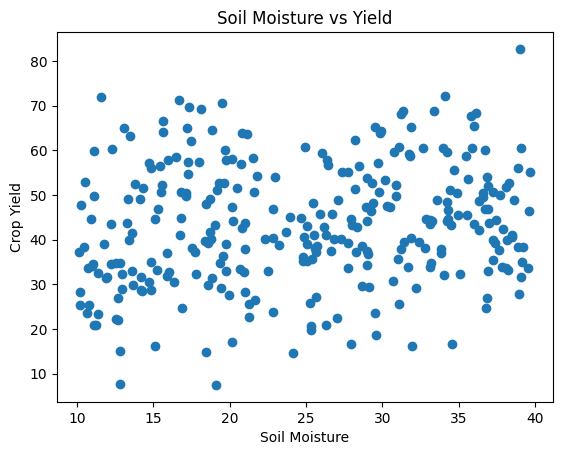

In [24]:
plt.scatter(data["soil_moisture"], data["yield"])

plt.xlabel("Soil Moisture")
plt.ylabel("Crop Yield")

plt.title("Soil Moisture vs Yield")
plt.show()

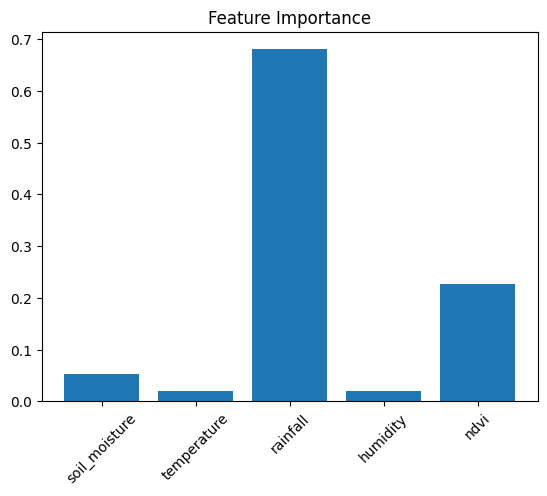

In [25]:
importance = model.feature_importances_

features = X.columns

plt.bar(features, importance)

plt.xticks(rotation=45)

plt.title("Feature Importance")
plt.show()

Text(0.5, 1.0, 'Crop Yield Distribution')

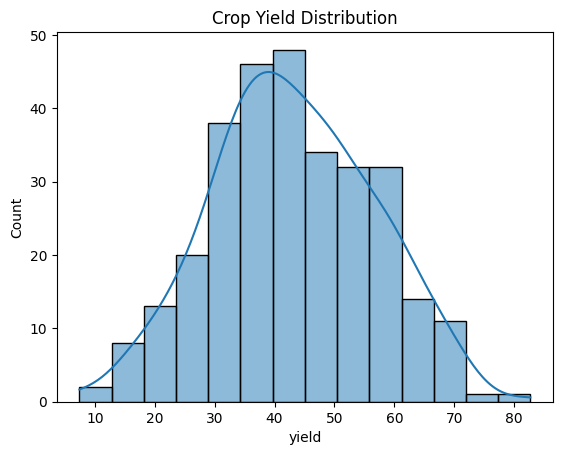

In [26]:
sns.histplot(data["yield"], kde=True)

plt.title("Crop Yield Distribution")

Text(0.5, 1.0, 'Actual vs Predicted Yield')

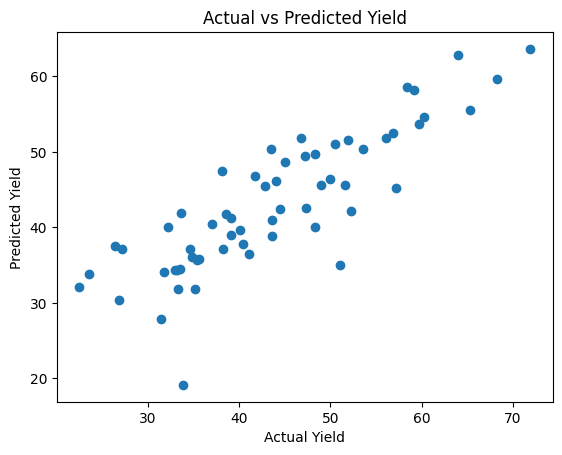

In [27]:
plt.scatter(y_test, pred)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Yield")

Text(0.5, 1.0, 'Residual Plot')

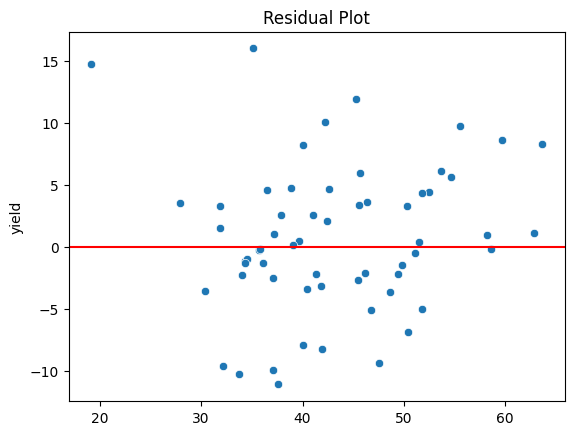

In [28]:
residuals = y_test - pred

sns.scatterplot(x=pred, y=residuals)

plt.axhline(0, color="red")

plt.title("Residual Plot")

Text(0.5, 1.0, 'NDVI vs Crop Yield')

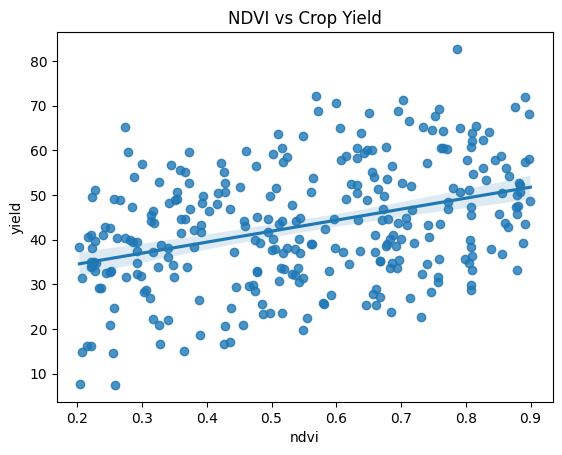

In [29]:
sns.regplot(
    x=data["ndvi"],
    y=data["yield"]
)

plt.title("NDVI vs Crop Yield")

Text(0.5, 1.0, 'Correlation with Yield')

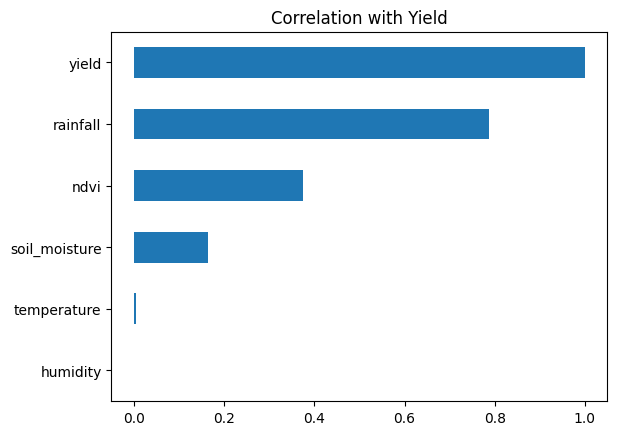

In [30]:
corr_with_yield = data.corr()["yield"].sort_values()

corr_with_yield.plot(kind="barh")

plt.title("Correlation with Yield")

Text(0.5, 1.0, 'Yield Trend')

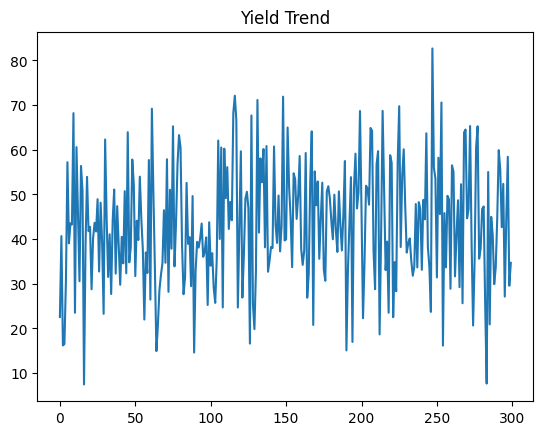

In [31]:
plt.plot(data["yield"])

plt.title("Yield Trend")

<Figure size 800x800 with 0 Axes>

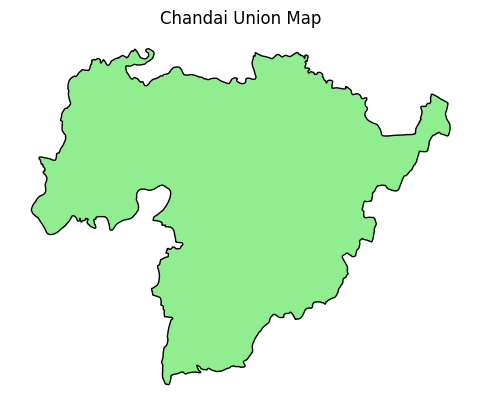

In [36]:
import geopandas as gpd
import matplotlib.pyplot as plt

shp = gpd.read_file("/content/Export_Output_2.shp")

plt.figure(figsize=(8,8))

shp.plot(
    edgecolor="black",
    facecolor="lightgreen",
    linewidth=1
)

plt.title("Chandai Union Map")
plt.axis("off")

plt.show()